## Ejemplo con datos reales: béisbol (Statcast) con deriva y clustering batch vs streaming

En este ejemplo usamos datos pitch-by-pitch (lanzamiento a lanzamiento) y tenemos dos objetivos:

1) Ver diferencias entre técnicas *batch* (k-means / DBSCAN / jerárquico) en un dataset real.
2) Simular datos que cambian con el tiempo (deriva intra-temporada) y comparar:
   - batch en el sentido clásico (entrenamos una vez y no actualizamos),
   - ventanas (re-entrenamos periódicamente),
   - streaming (actualización incremental con micro-lotes o microclústeres).


---

### Setup

```bash
pip install pandas numpy scikit-learn matplotlib pybaseball river

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.cluster import MiniBatchKMeans

from pybaseball import playerid_lookup, statcast_pitcher
from river import cluster


# Cargamos datos (un pitcher, una temporada)

In [14]:
# # Datos que cogemos para el ejemplo
# FIRST = "Gerrit"   # ejemplo
# LAST  = "Cole"     # ejemplo
# START = "2023-03-30"
# END   = "2023-10-01"
#
# # Buscamos MLBAM ID
# ids = playerid_lookup(LAST, FIRST)
# mlbam_id = int(ids.iloc[0]["key_mlbam"])
# print("MLBAM ID:", mlbam_id)
#
# # Descargamos Statcast del pitcher (pitch-level)
# raw = statcast_pitcher(START, END, mlbam_id)
#
# print(raw.shape)
# raw.head(3)


In [15]:
# raw.to_csv("statcast_pitcher.csv", index=False) # guardamos porque tarda un poco

In [16]:
# Ya hemos hecho la descarga antes, ahora solo leemos
raw = pd.read_csv("statcast_pitcher.csv")

In [17]:
raw.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2023-09-27,96.1,-2.01,5.76,"Cole, Gerrit",666182,543037,field_out,hit_into_play,...,1.0,0.97,0.65,0.65,41.0,-0.752419,8.168778,35.641869,29.691420,21.694452
1,SL,2023-09-27,89.2,-2.05,5.77,"Cole, Gerrit",666182,543037,NaN,ball,...,1.0,2.91,-0.42,-0.42,38.9,NaN,NaN,NaN,NaN,NaN
2,FF,2023-09-27,96.9,-2.16,5.74,"Cole, Gerrit",666182,543037,NaN,called_strike,...,1.0,1.03,0.77,0.77,37.9,NaN,NaN,NaN,NaN,NaN
3,FC,2023-09-27,91.0,-2.07,5.82,"Cole, Gerrit",543807,543037,field_out,hit_into_play,...,1.0,2.04,-0.50,-0.50,43.6,1.480335,-1.123581,35.379770,43.610423,19.869312
4,FF,2023-09-27,97.1,-2.10,5.83,"Cole, Gerrit",595281,543037,strikeout,swinging_strike,...,1.0,0.96,0.59,-0.59,41.5,11.141652,2.961098,28.462213,37.486262,22.341926


## Preparación: features numéricas + limpieza

Elegimos variables que suelen separar tipos de lanzamiento:

release_speed (velocidad)

release_spin_rate (spin)

pfx_x, pfx_z (movimiento)

(opcional) plate_x, plate_z (localización en el plato)

In [18]:
# Preparamos bien el csv
df = raw.copy()

features = ["release_speed", "release_spin_rate", "pfx_x", "pfx_z"]
# Se podría meter también localización:
# features += ["plate_x", "plate_z"]

# Nos quedamos con columnas necesarias y quitamos NA
keep = ["game_date", "pitch_type"] + features
df = df[keep].dropna().copy()

# Orden temporal (stream)
df["game_date"] = pd.to_datetime(df["game_date"])
df = df.sort_values("game_date").reset_index(drop=True)

print(df.shape)
df.head()


(3281, 6)


,game_date,pitch_type,release_speed,release_spin_rate,pfx_x,pfx_z
0,2023-03-30,FF,95.1,2326.0,-1.04,1.49
1,2023-03-30,FF,97.3,2465.0,-0.88,1.33
2,2023-03-30,CH,89.6,1521.0,-1.02,1.03
3,2023-03-30,FF,99.5,2436.0,-1.25,1.40
4,2023-03-30,FF,97.3,2515.0,-0.96,1.43


In [19]:
df["pitch_type"].value_counts(dropna=False)


pitch_type
FF    1737
SL     683
KC     396
CH     233
FC     231
SI       1
Name: count, dtype: int64

Tipos de lanzamientos incluidos en nuestros datos:

- Fastballs (rectas y variantes) (FF = Four-seam fastball (4 costuras), FC = Cutter (cortada), SI = Sinker (hundida))
- Offspeed (cambios / dedos) (CH = Changeup (cambio))
- Breaking balls (curvas / sliders) (SL = Slider, KC = Knuckle-curve (curva nudillera))

In [20]:
X = df[features].values
scaler = StandardScaler()
Xz = scaler.fit_transform(X)


In [21]:
Xz

array([[ 0.49665906, -0.38131128, -1.17739714,  0.78508779],
       [ 0.93669102,  0.11951798, -0.93758524,  0.60689143],
       [-0.60342085, -3.28179732, -1.14742065,  0.27277324],
       ...,
       [-0.18339034,  0.46541446,  0.69613335,  0.51779324],
       [-2.30354434,  1.21125372,  1.38559257, -2.50040774],
       [ 0.69667358, -0.35969275, -0.59285563,  0.81849961]])

En clustering no supervisado rara vez existe un “k verdadero” único. En práctica se suele combinar:

- Criterios internos (sin etiquetas): inertia/elbow, silhouette, Calinski–Harabasz, Davies–Bouldin, gap statistic.

- Criterios por modelo (en el caso de modelos probabilísticos como GMM): BIC/AIC.

- Estabilidad: repetir el clustering con distintas semillas/submuestras y vemos si la partición es consistente.

En este notebook tenemos una etiqueta informativa (pitch_type) que no usamos para entrenar, pero sí la podemos usar para evaluar si $k$ separa bien tipos de lanzamiento.

### 1) Elbow + Silhouette + CH + DB (para $k$-means)

- $W(S)$ baja siempre al aumentar $k$: buscamos un codo (rendimientos decrecientes).

- Silhouette ∈ [-1, 1]: cuanto más alto, mejor separación/compacidad.

- Calinski–Harabasz: cuanto más alto, mejor.

- Davies–Bouldin: cuanto más bajo, mejor.

Importante: estos índices asumen (implícitamente) métricas tipo distancia euclídea y suelen ser más coherentes si se estandariza).

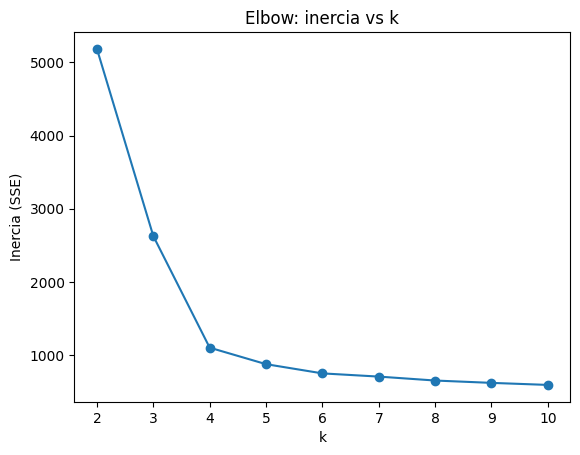

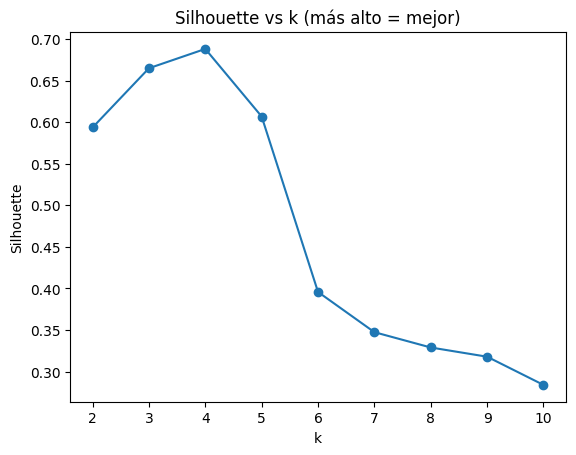

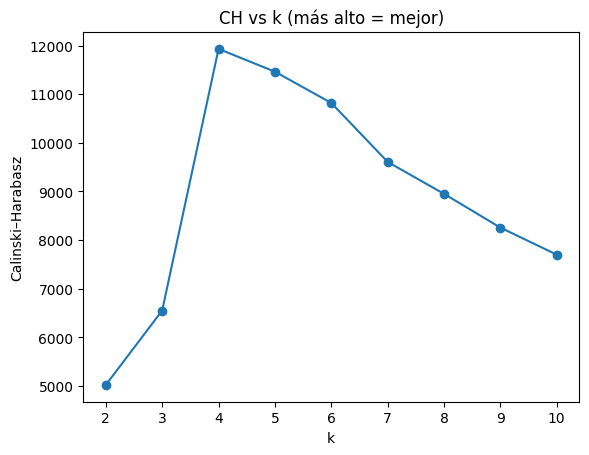

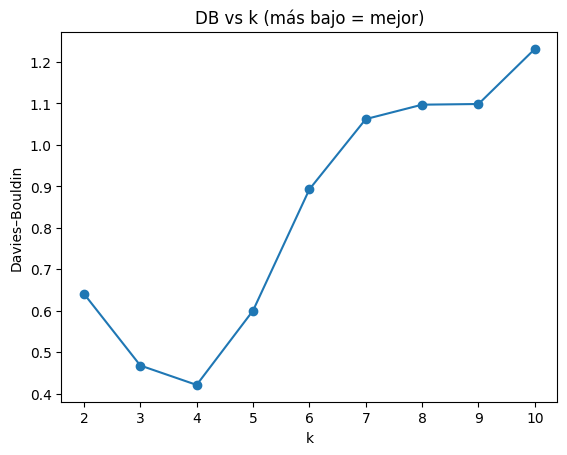

In [22]:
ks = range(2, 11)

inertias = []
sil = []
ch = []
db = []

for k in ks:
    km = KMeans(n_clusters=k, n_init="auto", random_state=0)
    labels = km.fit_predict(Xz)

    inertias.append(km.inertia_)
    sil.append(silhouette_score(Xz, labels))
    ch.append(calinski_harabasz_score(Xz, labels))
    db.append(davies_bouldin_score(Xz, labels))

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inercia (SSE)")
plt.title("Elbow: inercia vs k")
plt.show()

plt.figure()
plt.plot(list(ks), sil, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k (más alto = mejor)")
plt.show()

plt.figure()
plt.plot(list(ks), ch, marker="o")
plt.xlabel("k")
plt.ylabel("Calinski–Harabasz")
plt.title("CH vs k (más alto = mejor)")
plt.show()

plt.figure()
plt.plot(list(ks), db, marker="o")
plt.xlabel("k")
plt.ylabel("Davies–Bouldin")
plt.title("DB vs k (más bajo = mejor)")
plt.show()

### 3) Selección de k en GMM (BIC/AIC)

En GaussianMixture, lo natural es comparar BIC (penaliza más la complejidad) y AIC.

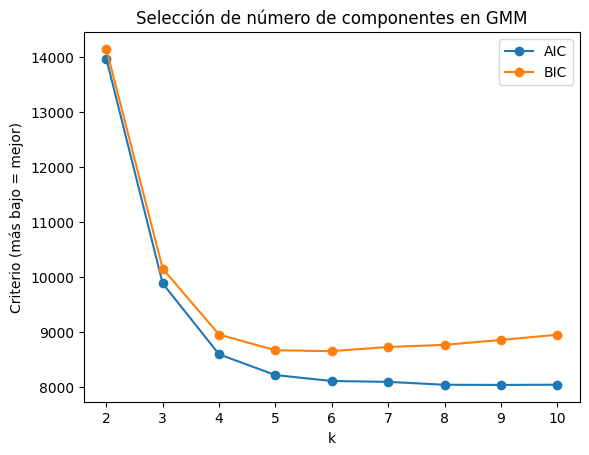

In [23]:
aic = []
bic = []

for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(Xz)
    aic.append(gmm.aic(Xz))
    bic.append(gmm.bic(Xz))

plt.figure()
plt.plot(list(ks), aic, marker="o", label="AIC")
plt.plot(list(ks), bic, marker="o", label="BIC")
plt.xlabel("k")
plt.ylabel("Criterio (más bajo = mejor)")
plt.title("Selección de número de componentes en GMM")
plt.legend()
plt.show()

## k-means

In [24]:
k = 4  # podemos probar varios valores, por ejemplo entre 3 y 6
km = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_km = km.fit_predict(Xz)

df["km"] = lab_km
df.groupby(["km", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
km,,,,,,
0,0,207,0,0,0,682
1,0,24,1737,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,1


## Dendrograma (con muestreo para que sea legible)

Los dendrogramas con miles de puntos se vuelven ilegibles; para visualización es mejor submuestrear.

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

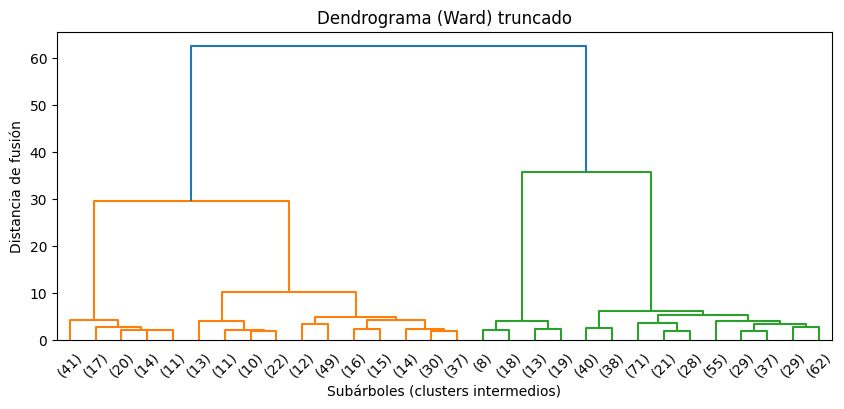

In [26]:
rng = np.random.RandomState(0)

# Cogemos la muestra aleatoria
n_sample = min(800, len(Xz))
idx = rng.choice(len(Xz), size=n_sample, replace=False) # sin reemplazo
Xs = Xz[idx]

# Ward: muy usado con datos estandarizados y distancia euclídea
Z = linkage(Xs, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Dendrograma (Ward) truncado")
plt.xlabel("Subárboles (clusters intermedios)")
plt.ylabel("Distancia de fusión")
plt.show()

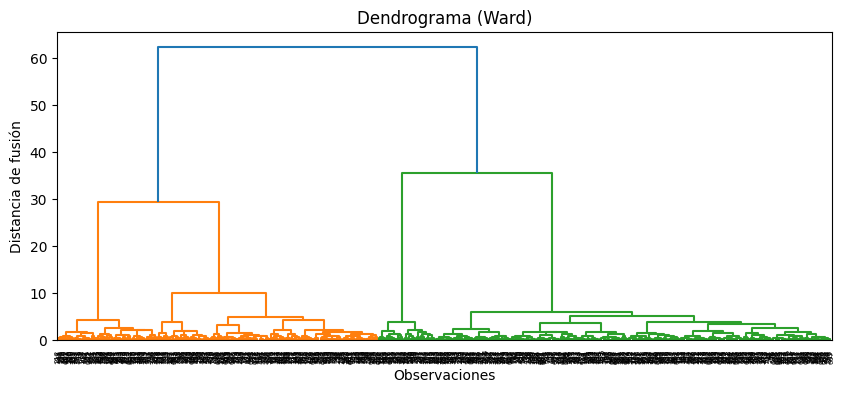

In [27]:
plt.figure(figsize=(10, 4))
dendrogram(Z)
plt.title("Dendrograma (Ward)")
plt.xlabel("Observaciones")
plt.ylabel("Distancia de fusión")
plt.show()

### Obtener clusters cortando el dendrograma (dos formas)

**A) Cortar por número de clusters (k)**

In [28]:
mk = 4
labels_h = fcluster(Z, t=k, criterion="maxclust")

**B) Cortar por umbral**

In [29]:
t = 12.0
labels_h2 = fcluster(Z, t=t, criterion="distance")

### AgglomerativeClustering (sklearn) para todo el dataset
Una veez decidido $k$ (por dendrograma o por índices), podemos etiquetar todo el dataset:

In [30]:
k = 4
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
lab_agg = agg.fit_predict(Xz)

df["agg_ward"] = lab_agg
df.groupby(["agg_ward", "pitch_type"]).size().unstack(fill_value=0)

pitch_type,CH,FC,FF,KC,SI,SL
agg_ward,,,,,,
0,0,228,6,0,0,683
1,0,3,1731,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,0


## Gaussian Mixture Model (GMM)

GMM permite clústeres elípticos y da probabilidades (útil para “mezclas” de lanzamientos).

In [31]:
gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
lab_gmm = gmm.fit_predict(Xz)

df["gmm"] = lab_gmm
df.groupby(["gmm", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
gmm,,,,,,
0,0,228,5,0,0,683
1,0,3,1732,0,1,0
2,233,0,0,0,0,0
3,0,0,0,396,0,0


In [32]:
lab_gmm

array([1, 1, 2, ..., 0, 3, 1])

In [43]:
df["gmm"]

0       1
1       1
2       2
3       1
4       1
       ..
3276    1
3277    1
3278    0
3279    3
3280    1
Name: gmm, Length: 3281, dtype: int64

## DBSCAN (densidad + outliers)

DBSCAN no necesita k y detecta ruido. Es fácil que marque muchos -1 si eps no está bien.

In [33]:
db = DBSCAN(eps=0.9, min_samples=15)  # probar distintos valores de los parámetros
lab_db = db.fit_predict(Xz)

df["dbscan"] = lab_db
df["dbscan"].value_counts().head()
df.groupby(["dbscan", "pitch_type"]).size().unstack(fill_value=0)


pitch_type,CH,FC,FF,KC,SI,SL
dbscan,,,,,,
0,0,231,1737,396,1,683
1,233,0,0,0,0,0


Visualizamos los resultados:

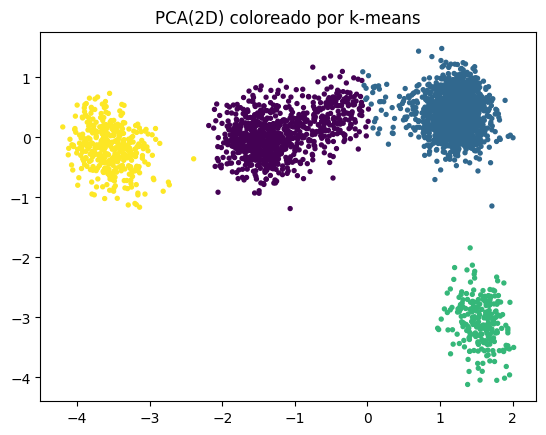

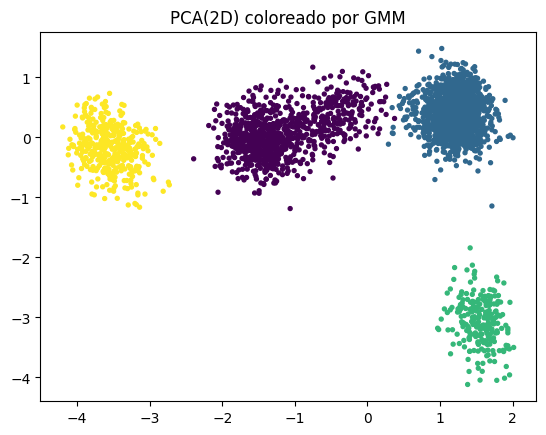

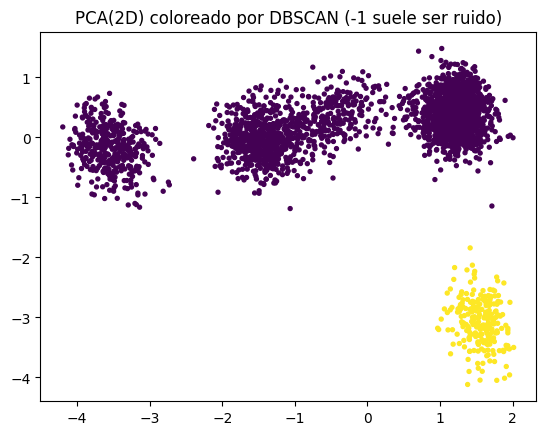

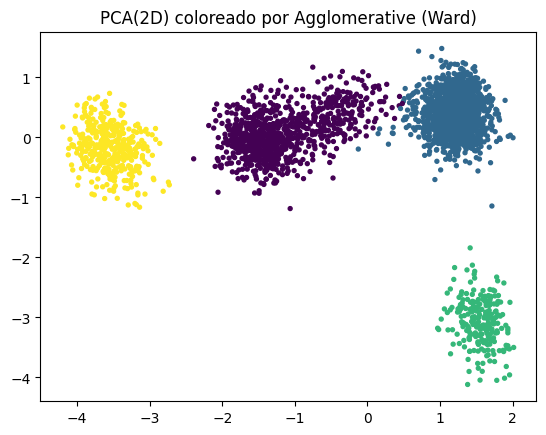

In [34]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(Xz)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, c=df["km"])
plt.title("PCA(2D) coloreado por k-means")
plt.show()

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, c=df["gmm"])
plt.title("PCA(2D) coloreado por GMM")
plt.show()

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, c=df["dbscan"])
plt.title("PCA(2D) coloreado por DBSCAN (-1 suele ser ruido)")
plt.show()

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], s=8, c=df["agg_ward"])
plt.title("PCA(2D) coloreado por Agglomerative (Ward)")
plt.show()


#  Deriva temporal: ¿cambian los lanzamientos con el tiempo?

Veremos dos formas simples de deriva:

   - Cambios en centroides (velocidad/spin/movimiento).

   - Cambios en la mezcla de tipos de lanzamiento.

## Señal de deriva “naive”: media móvil de velocidad

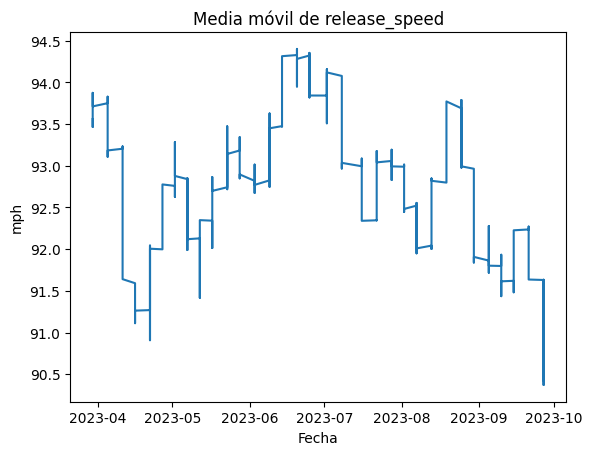

In [35]:
df["release_speed_ma"] = df["release_speed"].rolling(200, min_periods=50).mean()

plt.figure()
plt.plot(df["game_date"], df["release_speed_ma"])
plt.title("Media móvil de release_speed")
plt.xlabel("Fecha")
plt.ylabel("mph")
plt.show()


## Mezcla de pitch_type por bloques temporales

In [36]:
# Partimos temporada en 2 mitades
mid = df["game_date"].quantile(0.5)
df["half"] = np.where(df["game_date"] <= mid, "H1", "H2")

# proporción de tipos de tiro por temporaada
mix = (
    df.groupby(["half", "pitch_type"])
      .size()
      .groupby(level=0)
      .apply(lambda s: s / s.sum())
      .unstack(fill_value=0)
)
mix


,pitch_type,CH,FC,FF,KC,SI,SL
half,half,,,,,,
H1,H1,0.074955,0.0232,0.563950,0.119572,0.000000,0.218322
H2,H2,0.066875,0.1200,0.493125,0.121875,0.000625,0.197500


# Comparativa batch vs ventanas vs streaming

Si el proceso cambia, un modelo “entrenado una vez” puede quedarse obsoleto.

#### Tres niveles de “online”

1. Batch fijo: entreno una vez y no toco más.

     - Pros: simple.
     - Contras: con deriva, se queda obsoleto.

2. Ventanas: re-entreno cada cierto tiempo usando solo datos recientes.

     - Pros: se adapta a deriva, mantiene interpretación temporal (“clústeres del último mes”).
     - Contras: recalcular cuesta; cambios a saltos.

3. Streaming incremental:

     - Micro-lotes (MiniBatchKMeans): actualiza centroides con partial_fit.
     - Microclústeres (DenStream, etc.): mantiene “resúmenes” y olvida con decaimiento; maneja ruido/densidad.

## Batch “entrenar una vez” y congelar

In [37]:
h1 = df["half"] == "H1"
h2 = df["half"] == "H2"

km_h1 = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_h1 = km_h1.fit_predict(Xz[h1])

# Etiquetas predichas en H2 usando centroides de H1
lab_h2_pred = km_h1.predict(Xz[h2])

# Para comparar "clustering de H2 entrenando en H2" vs "clustering H2 con modelo viejo"
km_h2 = KMeans(n_clusters=k, n_init="auto", random_state=0)
lab_h2_fit = km_h2.fit_predict(Xz[h2])

ari = adjusted_rand_score(lab_h2_fit, lab_h2_pred)
print("ARI(H2-fit vs H2-pred con centroides H1):", ari)
# ARI alto es bueno

ARI(H2-fit vs H2-pred con centroides H1): 0.9869682749123118


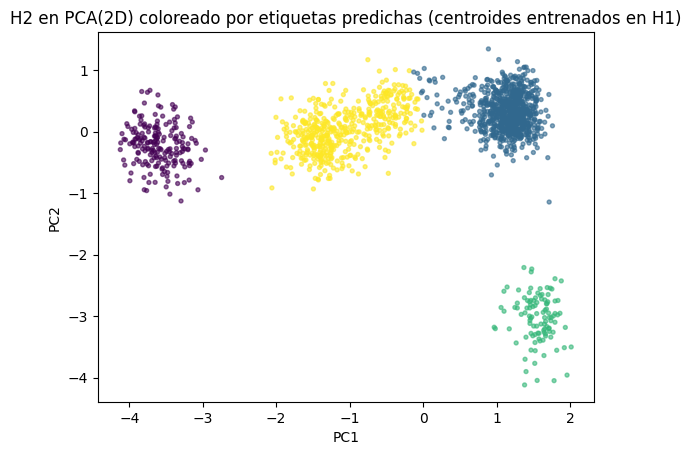

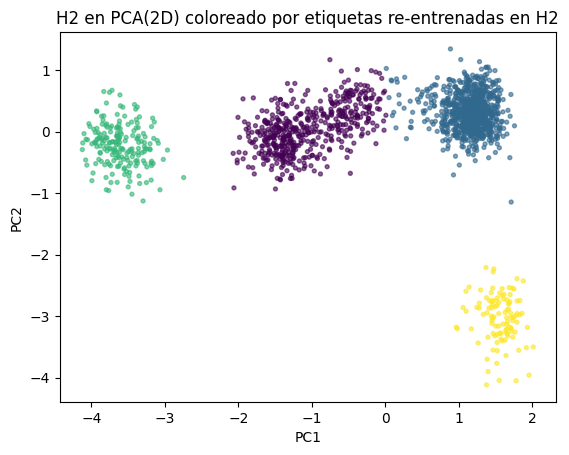

In [38]:
# PCA ajustado en TOD (para que el plano sea común)
pca = PCA(n_components=2, random_state=0)
Xpca = pca.fit_transform(Xz)

Xpca_h2 = Xpca[h2.values]

plt.figure()
plt.scatter(Xpca_h2[:, 0], Xpca_h2[:, 1], s=8, alpha=0.6, c=lab_h2_pred)
plt.title("H2 en PCA(2D) coloreado por etiquetas predichas (centroides entrenados en H1)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

plt.figure()
plt.scatter(Xpca_h2[:, 0], Xpca_h2[:, 1], s=8, alpha=0.6, c=lab_h2_fit)
plt.title("H2 en PCA(2D) coloreado por etiquetas re-entrenadas en H2")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

## Ventanas: re-entrenar periódicamente (sliding/bloques)
Aquí hacemos “tumbling”: cada W lanzamientos, re-entrenamos $k$-means solo con esa ventana y guardamos centroides (o parámetros).
La idea es que el modelo se adapta si hay deriva.

In [39]:
W = 500  # tamaño de ventana en nº de lanzamientos
centroids = []
dates = []

for start in range(0, len(df), W):
    end = min(start + W, len(df))
    Xw = Xz[start:end]

    km_w = KMeans(n_clusters=k, n_init="auto", random_state=0)
    km_w.fit(Xw)

    centroids.append(km_w.cluster_centers_)
    dates.append(df.loc[end-1, "game_date"]) # fecha del último punto de la ventana

centroids = np.array(centroids)  # (n_windows, k, d)
print("n_windows:", centroids.shape[0])


n_windows: 7


Para visualizar “deriva de centroides” de forma simple, miramos solo la componente release_speed (feature 0):

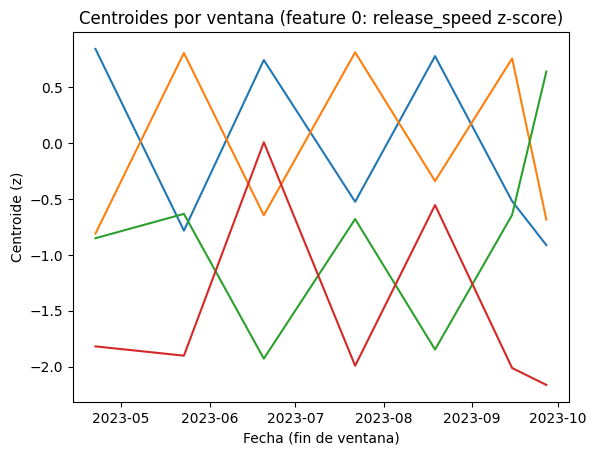

In [40]:
plt.figure()
for c in range(k):
    plt.plot(dates, centroids[:, c, 0])
plt.title("Centroides por ventana (feature 0: release_speed z-score)")
plt.xlabel("Fecha (fin de ventana)")
plt.ylabel("Centroide (z)")
plt.show()


¿Qué miramos en este gráfico?:

 - Si los centroides se desplazan con el tiempo, hay deriva.
 - Si “cambia el orden” de centroides entre ventanas, ojo: el label 0,1,2,3 no está alineado entre ventanas.

## Streaming incremental: MiniBatchKMeans (online por micro-lotes)

MiniBatchKMeans permite partial_fit, que actualiza centroides con micro-lotes:

- cambios más suaves que las ventanas,
- coste por paso controlado,
- pero sigue siendo “$k$-means” (asume clusters compactos tipo esferas).

`MiniBatchKMeans` es una versión “streaming-friendly” de $k$-means: en vez de recalcular los centroides usando **todos** los datos (batch), procesa **mini-lotes** de tamaño $B$ y va actualizando los centroides de forma incremental, sin guardar el histórico.

Supongamos que tenemos $k$ centroides $\mu_1,\dots,\mu_k$. Llega un mini-lote $X_b$ con $B$ puntos.

1) **Asignación (igual que $k$-means clásico)**
Para cada punto del mini-lote, se busca el centroide más cercano:
$$c(x)=\arg\min_j \|x-\mu_j\|^2$$

2) **Actualización incremental de centroides**
Para cada centroide $j$, miramos qué puntos del mini-lote han sido asignados a ese cluster.
En k-means batch haríamos: “nuevo centroide = media de *todos* los puntos asignados (en todo el dataset)”.

En mini-batch no guardamos el histórico. En su lugar, mantenemos un contador $n_j$ (cuántos puntos han contribuido al centroide $j$) y actualizamos el centroide como una **media acumulada**.

Si llega un punto $x$ asignado al cluster $j$, la actualización típica es:
$$n_j \leftarrow n_j + 1$$
$$\mu_j \leftarrow \mu_j + \frac{1}{n_j}(x-\mu_j)$$

Esto es exactamente la fórmula de una media online:
- al principio (cuando $n_j$ es pequeño) el centroide se mueve mucho,
- más tarde (cuando $n_j$ es grande) el centroide se mueve poquito.



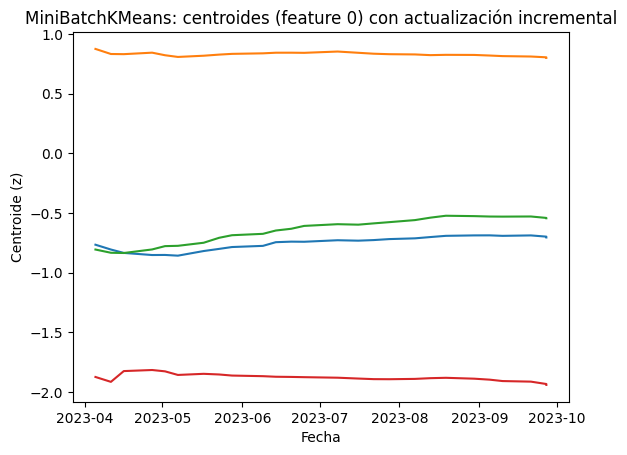

In [41]:
centroids_stream = []
dates_stream = []
k=4
B = 128  # tamaño del micro-lote

mbk = MiniBatchKMeans(n_clusters=k, random_state=0, batch_size=128)

for start in range(0, len(df), B):
    end = min(start + B, len(df))
    Xb = Xz[start:end]

    mbk.partial_fit(Xb)
    # Guardamos centroides para inspección
    centroids_stream.append(mbk.cluster_centers_.copy())
    dates_stream.append(df.loc[end-1, "game_date"])

centroids_stream = np.array(centroids_stream)

plt.figure()
for c in range(k):
    plt.plot(dates_stream, centroids_stream[:, c, 0])
plt.title("MiniBatchKMeans: centroides (feature 0) con actualización incremental")
plt.xlabel("Fecha")
plt.ylabel("Centroide (z)")
plt.show()


Qué comparar con ventanas:

- Ventanas: cambios “a saltos” (reentrenamos).
- MiniBatch: cambios más suaves y continuos.
- Si MiniBatch “se adapta demasiado” (mucho ruido), subir B o usar estrategias de suavizado.

## Streaming por densidad (microclústeres): DenStream

DenStream (https://riverml.xyz/dev/api/cluster/DenStream/) es un algoritmo de clustering en streaming basado en densidad (familia DBSCAN) pensado para flujos no estacionarios y con ruido. DenStream intenta descubrir clústeres de forma arbitraria y además mantiene explícitamente una noción de outliers y olvido temporal.

En vez de guardar todos los puntos, DenStream mantiene un conjunto pequeño de microclústeres (resúmenes) que se actualizan online y “pierden peso” con el tiempo.


DenStream mantiene dos tipos de microclústeres:

- **p-micro-clusters (potenciales)**: regiones densas “consolidadas” que son candidatas a formar clústeres reales.
- **o-micro-clusters (outlier)**: regiones aún poco densas; si no reciben más puntos, se desvanecen y se eliminan.

Cada microclúster es un resumen (no una lista de puntos) con:
- un centro (centroide),
- un peso (número efectivo de puntos, con decaimiento),
- y típicamente estadísticas para estimar dispersión/radio.

---

Cuando llega un nuevo punto $x_t$, DenStream hace esto:

1) **Aplicar olvido (decaimiento temporal)**
Los microclústeres pierden peso con el tiempo para que lo reciente cuente más: si un microclúster no recibe nuevos puntos, su peso cae y puede desaparecer. Esto permite adaptarse a deriva.

2) **Buscar el mejor microclúster candidato**
Se intenta asignar $x_t$ al microclúster más cercano (primero a los potenciales, y si no encaja, a los de outliers), siempre que esté dentro de un radio controlado por $\varepsilon$.

3) **Si “encaja”: actualizar el microclúster**
Si la distancia es suficientemente pequeña (y/o el radio resultante no excede $\varepsilon$), se actualiza el resumen:
    - el centro se desplaza ligeramente hacia $x_t$,
    - el peso aumenta (y luego seguirá decayendo con el tiempo).

4) **Si NO encaja: crear/actualizar un o-micro-cluster**
Si no pertenece a ninguno, se crea (o se refuerza) un microclúster de outlier.

5) **Promoción y poda**
Periódicamente:
    - si un o-micro-cluster acumula suficiente peso, se promueve a p-micro-cluster.
    - si un microclúster pierde demasiado peso (por olvido) o no es suficientemente denso, se elimina.

Resultado: el modelo se actualiza online, ocupa memoria acotada, detecta novedad (outliers) y se adapta a cambios.

---

## Parámetros

En la implementación de `river`, los parámetros más importantes son:

- **`epsilon (ε)`**: “radio” máximo de un microclúster (similar a `eps` en DBSCAN).
  - Más grande ⇒ absorbe más puntos ⇒ menos microclústeres (y más riesgo de mezclar cosas).
  - Más pequeño ⇒ más microclústeres/outliers (y más sensibilidad al ruido).
  - Depende de la escala.

- **`decaying_factor (λ)`**: cuánto se “olvida” lo antiguo.
  - λ mayor ⇒ olvido más rápido ⇒ adaptación más rápida (pero más inestable).
  - λ menor ⇒ memoria más larga ⇒ modelo más estable (pero reacciona lento a deriva).

- **`beta`**: umbral relativo para separar outliers respecto a microclústeres “core”.
  - Valores típicos en (0,1]; cuanto más bajo, más fácil “tolerar” outliers antes de consolidarlos.

- **`mu`**: peso mínimo para que un microclúster se considere suficientemente denso (“core/potencial”).
  - Más alto ⇒ exige más evidencia para consolidar clusters (más conservador).
  - Más bajo ⇒ clusters aparecen antes (más sensible).

- **`n_samples_init`**: número de puntos iniciales usados para arrancar el modelo.
  - Si es muy bajo, el arranque es ruidoso; si es alto, tarda más en empezar.

- **`stream_speed`**: escala temporal (cómo de rápido avanza el tiempo para el decaimiento). Útil si “un paso” del stream equivale a 1 punto, 1 segundo, 1 sesión, etc.

---

- Cao, F., Ester, M., Qian, W., & Zhou, A. (2006). *Density-Based Clustering over an Evolving Data Stream with Noise* (DenStream).

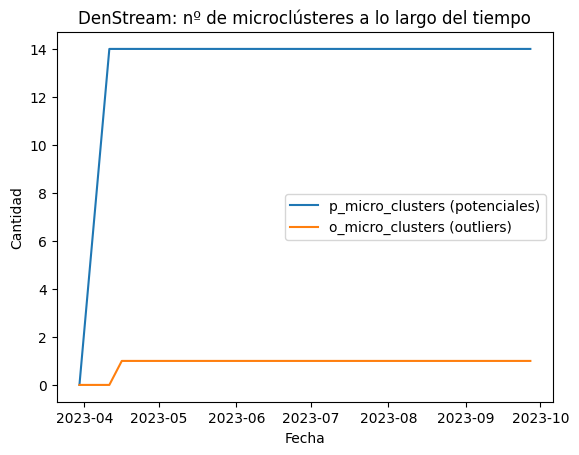

In [45]:
from river import cluster

den = cluster.DenStream(
    decaying_factor=0.01,  # 0.001–0.05 según deriva
    beta=0.5,
    mu=3.0,
    epsilon=0.3,
    n_samples_init=200,
    stream_speed=100
)

# Creamos nombres para las features estandarizadas
cols = [f"z_{c}" for c in features]

n_p, n_o, dates_ds = [], [], []

for i in range(len(df)):
    # construimos dict {feature: value} con Xz (estandarizado)
    x = {cols[j]: float(Xz[i, j]) for j in range(len(features))}

    den.learn_one(x)

    # Estos atributos pueden variar según versión; usamos getattr para evitar errores
    p = getattr(den, "p_micro_clusters", None)
    o = getattr(den, "o_micro_clusters", None)

    # Muestreamos cada 200 puntos para no guardar todo
    if (i % 200 == 0) and (p is not None) and (o is not None):
        n_p.append(len(p))
        n_o.append(len(o))
        dates_ds.append(df.loc[i, "game_date"])

plt.figure()
plt.plot(dates_ds, n_p, label="p_micro_clusters (potenciales)")
plt.plot(dates_ds, n_o, label="o_micro_clusters (outliers)")
plt.title("DenStream: nº de microclústeres a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

Interpretación:

- Suben outliers y luego bajan: aparece comportamiento nuevo que luego “se estabiliza”.

- Aumentan potenciales de forma sostenida: el stream se está volviendo más multimodal (más “tipos” de patrones).

- Todo colapsa a pocos microclústeres: epsilon puede ser demasiado grande (o el stream es realmente homogéneo).